In [ ]:
# === SETUP: load the provided files (regenerate them if missing) ===
import os
import numpy as np
import pandas as pd

# Each sensor is a linear mix of a few latent machine states + noise, so the 24
# columns are highly correlated -> exactly the structure PCA exploits.
# spec: (name, unit, group, c_load, c_wear, c_thermal, c_vib, base, scale, noise)
SENSORS = [
    ("temp_bearing",   "C",   "thermal",   0.2, 0.6, 0.9, 0.1, 66, 6, 0.30),
    ("temp_motor",     "C",   "thermal",   0.3, 0.4, 0.9, 0.1, 70, 7, 0.30),
    ("temp_gearbox",   "C",   "thermal",   0.2, 0.5, 0.8, 0.2, 62, 6, 0.35),
    ("oil_temp",       "C",   "thermal",   0.2, 0.5, 0.7, 0.1, 58, 5, 0.35),
    ("temp_ambient",   "C",   "thermal",   0.0, 0.0, 0.3, 0.0, 28, 2, 0.60),
    ("vibration_x",    "mm/s","vibration", 0.4, 0.3, 0.1, 0.9, 2.2, 0.6, 0.30),
    ("vibration_y",    "mm/s","vibration", 0.4, 0.3, 0.1, 0.9, 2.0, 0.6, 0.30),
    ("vibration_z",    "mm/s","vibration", 0.3, 0.4, 0.1, 0.8, 1.8, 0.5, 0.35),
    ("acoustic_db",    "dB",  "vibration", 0.3, 0.3, 0.1, 0.7, 78, 5, 0.40),
    ("rpm",            "rpm", "drive",     0.9, 0.1, 0.1, 0.3, 1800, 350, 0.25),
    ("spindle_speed",  "rpm", "drive",     0.9, 0.1, 0.1, 0.3, 6000, 1500, 0.25),
    ("feed_rate",      "mm/min","drive",   0.8, 0.1, 0.1, 0.2, 250, 60, 0.30),
    ("torque",         "Nm",  "drive",     0.8, 0.2, 0.1, 0.3, 120, 25, 0.30),
    ("power_kw",       "kW",  "power",     0.9, 0.2, 0.2, 0.2, 75, 18, 0.25),
    ("current_a",      "A",   "power",     0.8, 0.2, 0.2, 0.2, 22, 5, 0.30),
    ("current_b",      "A",   "power",     0.8, 0.2, 0.2, 0.2, 22, 5, 0.30),
    ("current_c",      "A",   "power",     0.8, 0.2, 0.2, 0.2, 22, 5, 0.30),
    ("load_pct",       "%",   "load",      0.9, 0.1, 0.1, 0.2, 65, 15, 0.25),
    ("pressure_in",    "bar", "hydraulic", 0.5, 0.2, 0.2, 0.2, 80, 12, 0.35),
    ("pressure_out",   "bar", "hydraulic", 0.5, 0.2, 0.2, 0.2, 60, 10, 0.35),
    ("coolant_flow",   "L/min","hydraulic",0.4, 0.2, 0.3, 0.1, 30, 6, 0.40),
    ("oil_level",      "%",   "hydraulic", 0.0,-0.4, 0.0, 0.0, 80, 8, 0.40),
    ("voltage",        "V",   "power",     0.0, 0.0, 0.0, 0.0, 415, 0.3, 1.0),  # near-constant
    ("humidity",       "%",   "ambient",   0.0, 0.0, 0.0, 0.0, 45, 0.2, 1.0),   # near-constant
]


def build_sensors(csv_path="machine_sensors.csv", xlsx_path="sensor_info.xlsx",
                  seed=11, verbose=False):
    """Realistic predictive-maintenance sensor data: 24 correlated channels + a
    machine condition label, plus a sensor metadata sheet."""
    rng = np.random.default_rng(seed)
    N = 2000

    load = rng.normal(0, 1, N)
    wear = rng.normal(0, 1, N)
    thermal = 0.5 * load + 0.8 * rng.normal(0, 1, N)
    vib = 0.4 * load + 0.3 * wear + 0.8 * rng.normal(0, 1, N)

    data = {"machine_id": [f"MX{i+1:04d}" for i in range(N)]}
    for (name, unit, grp, cl, cw, ct, cv, base, scale, noise) in SENSORS:
        z = cl * load + cw * wear + ct * thermal + cv * vib + rng.normal(0, noise, N)
        col = base + scale * z
        col = np.clip(col, 0, None)
        data[name] = col.round(2)
    df = pd.DataFrame(data)

    # machine condition from the latent wear/load/thermal state
    score = 0.6 * wear + 0.4 * load + 0.3 * thermal + rng.normal(0, 0.4, N)
    cond = np.where(score > 1.1, "Failure", np.where(score > 0.2, "Warning", "Normal"))
    df["condition"] = cond

    df.to_csv(csv_path, index=False)
    info = pd.DataFrame([(n, u, g) for (n, u, g, *_rest) in SENSORS],
                        columns=["sensor", "unit", "group"])
    info.to_excel(xlsx_path, index=False)

    if verbose:
        print("sensors:", df.shape, "| metadata:", info.shape)
        print("condition mix:", df["condition"].value_counts(normalize=True).round(3).to_dict())
        num = df.select_dtypes("number")
        print("near-constant (low std) cols:",
              list(num.std().sort_values().head(2).index))
        # how compressible is it?
        from numpy.linalg import svd
        Xs = (num - num.mean()) / num.std()
        s = svd(Xs.fillna(0).values, compute_uv=False)
        ev = (s ** 2) / (s ** 2).sum()
        print("variance in first 5 PCs:", round(ev[:5].sum(), 3))
    return df, info

if not (os.path.exists('machine_sensors.csv') and os.path.exists('sensor_info.xlsx')):
    build_sensors(); print('Generated dataset files.')
else:
    print('Found the provided dataset files.')

Generated dataset files.


In [ ]:
import pandas as pd, numpy as np
import matplotlib.pyplot as plt, seaborn as sns
sns.set_theme(style='whitegrid')

df = pd.read_csv('machine_sensors.csv')
info = pd.read_excel('sensor_info.xlsx')
sensors = [c for c in df.columns if c not in ('machine_id', 'condition')]
print('readings:', df.shape, '| sensors:', len(sensors))
df.head(3)

readings: (2000, 26) | sensors: 24


,machine_id,temp_bearing,temp_motor,temp_gearbox,oil_temp,temp_ambient,vibration_x,vibration_y,vibration_z,acoustic_db,...,current_b,current_c,load_pct,pressure_in,pressure_out,coolant_flow,oil_level,voltage,humidity,condition
0,MX0001,61.25,69.26,60.02,56.56,25.46,3.07,3.00,2.59,80.22,...,23.12,23.46,66.89,84.58,61.36,27.83,83.31,415.31,45.07,Normal
1,MX0002,72.66,78.22,68.98,62.77,29.08,2.43,2.26,2.21,78.41,...,30.54,25.88,84.32,90.57,71.68,35.50,77.44,414.68,45.11,Warning
2,MX0003,65.03,74.08,61.96,57.83,28.65,2.22,1.69,1.99,81.35,...,28.56,26.87,82.34,89.42,64.28,35.80,77.43,415.48,45.13,Warning


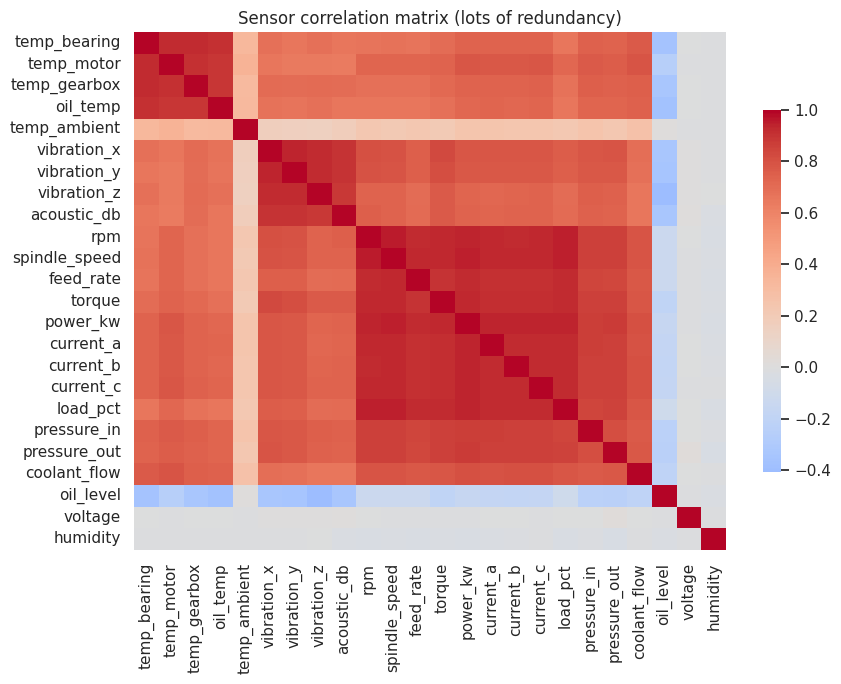

In [ ]:
# -----------------------------------------------------------
# 🔹 1A. 24 SENSORS — but how many move together?
# -----------------------------------------------------------
corr = df[sensors].corr()
fig, ax = plt.subplots(figsize=(9, 7))
sns.heatmap(corr, cmap='coolwarm', center=0, ax=ax,
            xticklabels=True, yticklabels=True, cbar_kws={'shrink': .7})
ax.set_title('Sensor correlation matrix (lots of redundancy)')
plt.tight_layout(); plt.show()

In [ ]:
# Count strongly-correlated sensor pairs (|r| > 0.8, excluding the diagonal)
c = corr.abs()
import numpy as np
pairs = (c.where(np.triu(np.ones(c.shape), k=1).astype(bool)) > 0.8).sum().sum()
print('sensor pairs with |correlation| > 0.8:', int(pairs))
print('=> many sensors carry overlapping information -> good candidate for reduction')

sensor pairs with |correlation| > 0.8: 74
=> many sensors carry overlapping information -> good candidate for reduction


In [ ]:
# 1. counts
# YOUR CODE HERE

# 2. most-correlated pair  (hint: stack the corr matrix, drop self-pairs, sort)
# YOUR CODE HERE
corr_stacked = corr.stack()
corr_sorted = corr_stacked[corr_stacked < 1].sort_values(ascending=False)
print('Most correlated sensor pair:')
print(corr_sorted.head(1))

# 3. Why 24 sensors is a problem:
# Having 24 sensors can be a problem due to redundancy (as seen in the high correlations), which can lead to:
# - Increased dimensionality: more features can lead to the 'curse of dimensionality', making models harder to train and less generalizeable.
# - Higher computational cost: more data to process requires more resources and time.
# - Multicollinearity: highly correlated features can destabilize models like linear regression.
# - Difficulty in interpretation: it's harder to understand the individual contribution of each sensor when many are measuring similar phenomena.

Most correlated sensor pair:
spindle_speed  rpm    0.951095
dtype: float64


In [ ]:
# -----------------------------------------------------------
# 🔹 2A. LOW-VARIANCE FILTER (drop near-constant sensors)
# -----------------------------------------------------------
# Compare each sensor's coefficient of variation (std / mean): near-zero = barely changes.
cov = (df[sensors].std() / df[sensors].mean()).abs().sort_values()
print('Lowest variation (candidates to drop):')
print(cov.head(3).round(4))
near_constant = cov.head(2).index.tolist()
print('\nDropping near-constant sensors:', near_constant)

Lowest variation (candidates to drop):
voltage         0.0007
humidity        0.0044
temp_ambient    0.0473
dtype: float64

Dropping near-constant sensors: ['voltage', 'humidity']


In [ ]:
# 1. drop near-constant
reduced = df[sensors].drop(columns=near_constant)

# 2. find & drop one of each highly-correlated (>0.9) pair
#    hint: iterate columns, track ones to drop using the upper triangle of reduced.corr().abs()
# YOUR CODE HERE
corr_reduced = reduced.corr().abs()
to_drop = set()
for i in range(len(corr_reduced.columns)):
    for j in range(i + 1, len(corr_reduced.columns)):
        if corr_reduced.iloc[i, j] > 0.9:
            # Keep one of the two, drop the other. Here we drop the second one (j).
            to_drop.add(corr_reduced.columns[j])

reduced = reduced.drop(columns=list(to_drop))
print(f"Dropped {len(to_drop)} highly correlated sensors.")

# 3. how many remain?
# YOUR CODE HERE
print(f"Number of sensors remaining after reduction: {reduced.shape[1]}")

Dropped 14 highly correlated sensors.
Number of sensors remaining after reduction: 8


In [ ]:
# -----------------------------------------------------------
# 🔹 3A. WHICH SENSORS SAY MOST ABOUT MACHINE CONDITION?
# -----------------------------------------------------------
from sklearn.feature_selection import mutual_info_classif
mi = mutual_info_classif(df[sensors], df['condition'], random_state=0)
mi = pd.Series(mi, index=sensors).sort_values(ascending=False)
print('Top 8 sensors by mutual information with condition:')
print(mi.head(8).round(3))

Top 8 sensors by mutual information with condition:
temp_bearing    0.362
temp_gearbox    0.320
oil_temp        0.316
temp_motor      0.278
pressure_out    0.245
current_b       0.242
power_kw        0.236
pressure_in     0.236
dtype: float64


/tmp/ipykernel_1990/2694992160.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=mi.head(10).index, y=mi.head(10).values, palette='viridis')


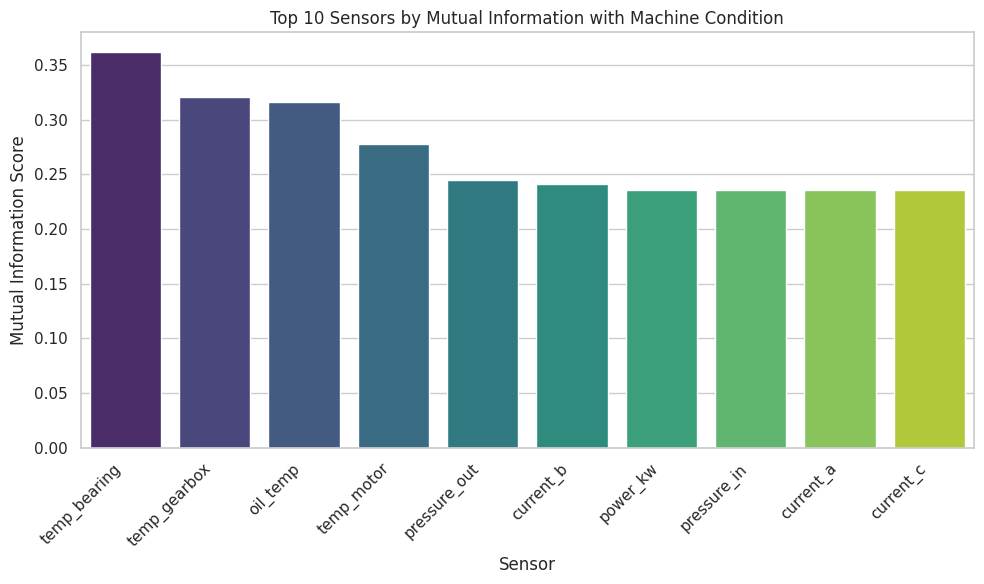


Sensor groups among the top 10 MI scores:
group
thermal      4
power        4
hydraulic    2
Name: count, dtype: int64


In [ ]:
# 1. bar chart of top-10 MI scores
# YOUR CODE HERE
plt.figure(figsize=(10, 6))
sns.barplot(x=mi.head(10).index, y=mi.head(10).values, palette='viridis')
plt.title('Top 10 Sensors by Mutual Information with Machine Condition')
plt.xlabel('Sensor')
plt.ylabel('Mutual Information Score')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

# 2. Which sensor group dominates? ...   (comment — use sensor_info to look up groups)
mi_with_groups = mi.to_frame(name='MI_Score').reset_index()
mi_with_groups.columns = ['sensor', 'MI_Score']
mi_with_groups = mi_with_groups.merge(info, on='sensor', how='left')

# Get the groups for the top 10 sensors
top_10_mi_groups = mi_with_groups.head(10)['group']

# Count the occurrences of each group
group_counts = top_10_mi_groups.value_counts()

print(f"\nSensor groups among the top 10 MI scores:\n{group_counts}")

# Based on the output, the 'thermal' and 'power' groups appear to dominate among the sensors most indicative of machine condition.

In [ ]:
# -----------------------------------------------------------
# 🔹 4A. STANDARDISE (essential!) THEN FIT PCA
# -----------------------------------------------------------
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

X = df[sensors].values
Xs = StandardScaler().fit_transform(X)      # PCA needs standardised inputs
pca = PCA().fit(Xs)
evr = pca.explained_variance_ratio_
print('Variance explained by the first 5 components:')
print((evr[:5] * 100).round(1))
print('First 5 components together:', round(evr[:5].sum() * 100, 1), '%')

Variance explained by the first 5 components:
[67.8  6.4  5.4  4.2  4.1]
First 5 components together: 87.9 %


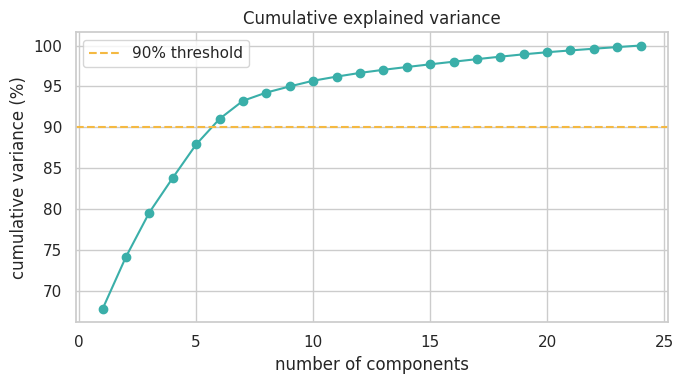

In [ ]:
# -----------------------------------------------------------
# 🔹 5A. CUMULATIVE EXPLAINED VARIANCE (the scree view)
# -----------------------------------------------------------
cum = np.cumsum(evr)
fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(range(1, len(cum) + 1), cum * 100, marker='o', color='#3AAFA9')
ax.axhline(90, color='#F4B942', ls='--', label='90% threshold')
ax.set_xlabel('number of components'); ax.set_ylabel('cumulative variance (%)')
ax.set_title('Cumulative explained variance'); ax.legend()
plt.tight_layout(); plt.show()

In [ ]:
# 1. components needed for 90% variance
# YOUR CODE HERE
components_for_90_variance = np.argmax(cum >= 0.90) + 1
print(f'{components_for_90_variance} components are needed to explain 90% of the variance.')

# 2. report the compression (24 -> ?)
# YOUR CODE HERE
original_sensors = len(sensors)
print(f'Compression: {original_sensors} sensors reduced to {components_for_90_variance} PCA components.')

6 components are needed to explain 90% of the variance.
Compression: 24 sensors reduced to 6 PCA components.


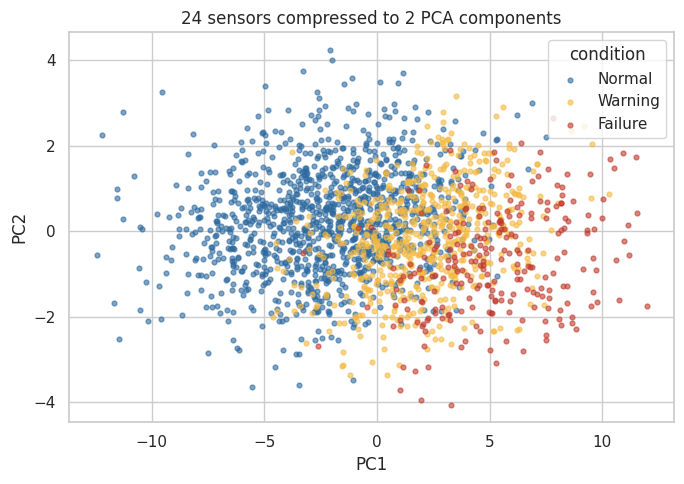

In [ ]:
# -----------------------------------------------------------
# 🔹 6A. COMPRESS 24 SENSORS -> 2 COMPONENTS, THEN PLOT
# -----------------------------------------------------------
X2 = PCA(n_components=2).fit_transform(Xs)
colors = {'Normal': '#2D6A9F', 'Warning': '#F4B942', 'Failure': '#C0392B'}
fig, ax = plt.subplots(figsize=(7, 5))
for cond, col in colors.items():
    m = df['condition'] == cond
    ax.scatter(X2[m, 0], X2[m, 1], s=12, alpha=0.6, color=col, label=cond)
ax.set_xlabel('PC1'); ax.set_ylabel('PC2'); ax.legend(title='condition')
ax.set_title('24 sensors compressed to 2 PCA components')
plt.tight_layout(); plt.show()

In [ ]:
# 1. Do the conditions separate? ...   (comment)

# 2. top-3 sensors loading on PC1
# YOUR CODE HERE


In [ ]:
# -----------------------------------------------------------
# 🔹 7A. QUICK CHECK — classify condition with ALL 24 vs a few PCs
# -----------------------------------------------------------
from sklearn.model_selection import cross_val_score
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import make_pipeline
y = df['condition']

full = make_pipeline(StandardScaler(), LogisticRegression(max_iter=1000))
pcap = make_pipeline(StandardScaler(), PCA(n_components=6), LogisticRegression(max_iter=1000))
s_full = cross_val_score(full, X, y, cv=5).mean()
s_pca = cross_val_score(pcap, X, y, cv=5).mean()
print(f'Accuracy with all 24 sensors : {s_full:.3f}')
print(f'Accuracy with 6 PCA components: {s_pca:.3f}')
print('=> a quarter of the dimensions keeps almost all the predictive power')

Accuracy with all 24 sensors : 0.748
Accuracy with 6 PCA components: 0.754
=> a quarter of the dimensions keeps almost all the predictive power


Accuracy with all 24 sensors : 0.748


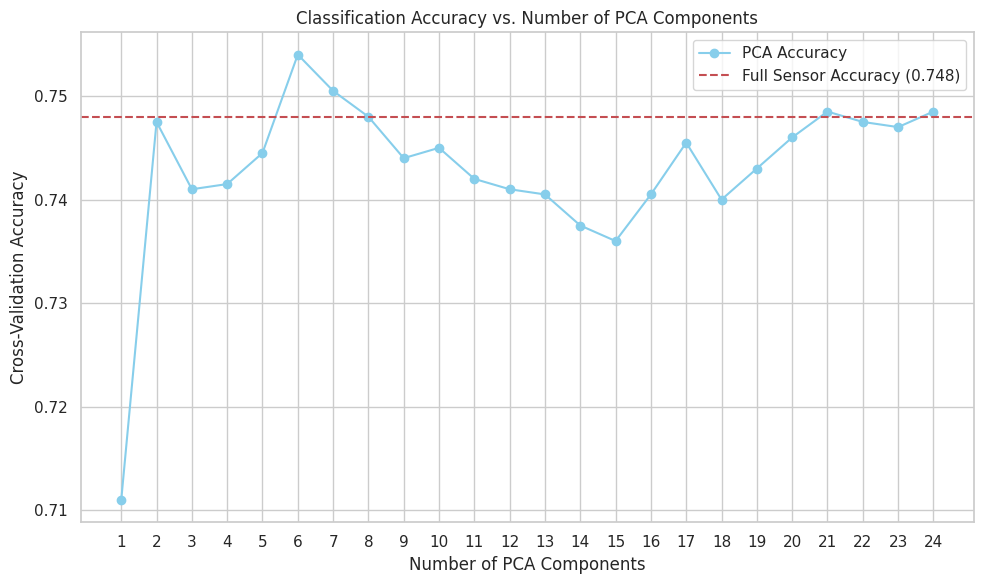

Fewest components to match ~99% of full accuracy: 2

This shows that a significantly reduced number of principal components can maintain nearly the same classification performance as using all original 24 sensors. This is valuable for reducing model complexity, training time, and potentially improving interpretability.


In [ ]:
# 1. accuracy vs number of PCA components
# YOUR CODE HERE
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import cross_val_score
import matplotlib.pyplot as plt

y = df['condition'] # Define the target variable

# Calculate full sensor accuracy first
full_model = make_pipeline(StandardScaler(), LogisticRegression(max_iter=1000))
s_full = cross_val_score(full_model, X, y, cv=5).mean()
print(f'Accuracy with all 24 sensors : {s_full:.3f}')

accuracies = []
num_components_range = range(1, len(sensors) + 1)

for n_comp in num_components_range:
    pcap_n = make_pipeline(StandardScaler(), PCA(n_components=n_comp), LogisticRegression(max_iter=1000))
    s_pca_n = cross_val_score(pcap_n, X, y, cv=5).mean()
    accuracies.append(s_pca_n)

plt.figure(figsize=(10, 6))
plt.plot(num_components_range, accuracies, marker='o', linestyle='-', color='skyblue', label='PCA Accuracy')
plt.axhline(y=s_full, color='r', linestyle='--', label=f'Full Sensor Accuracy ({s_full:.3f})')
plt.title('Classification Accuracy vs. Number of PCA Components')
plt.xlabel('Number of PCA Components')
plt.ylabel('Cross-Validation Accuracy')
plt.xticks(num_components_range)
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()
# 2. Fewest components that match full accuracy: ...   (comment)
threshold_accuracy = s_full * 0.99
fewest_components = None
for i, acc in enumerate(accuracies):
    if acc >= threshold_accuracy:
        fewest_components = num_components_range[i]
        break

if fewest_components is not None:
    print(f"Fewest components to match ~99% of full accuracy: {fewest_components}")
else:
    print("Could not achieve 99% of full accuracy even with all components.")

print(f"\nThis shows that a significantly reduced number of principal components can maintain nearly the same classification performance as using all original 24 sensors. This is valuable for reducing model complexity, training time, and potentially improving interpretability.")